In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_excel('../data/online_retail_II.xlsx', sheet_name='Year 2009-2010')

# First look
print(df.shape)
print(df.head())
print(df.dtypes)

(525461, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float

In [3]:
# Check for missing values and basic stats
print("Missing values:")
print(df.isnull().sum())

print("\nNegative quantities (returns):")
print(df[df['Quantity'] < 0].shape[0])

print("\nNegative prices:")
print(df[df['Price'] <= 0].shape[0])

print("\nDate range:")
print(df['InvoiceDate'].min())
print(df['InvoiceDate'].max())

print("\nNumber of unique customers:")
print(df['Customer ID'].nunique())

Missing values:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

Negative quantities (returns):
12326

Negative prices:
3690

Date range:
2009-12-01 07:45:00
2010-12-09 20:01:00

Number of unique customers:
4383


In [4]:
# Drop missing Customer IDs
df = df.dropna(subset=['Customer ID'])

# Remove returns and bad prices
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

# Convert Customer ID to integer
df['Customer ID'] = df['Customer ID'].astype(int)

# Create a total revenue column per row
df['TotalPrice'] = df['Quantity'] * df['Price']

# Confirm clean dataset
print("Clean dataset shape:", df.shape)
print("Unique customers:", df['Customer ID'].nunique())
print("Missing values remaining:", df.isnull().sum().sum())


Clean dataset shape: (407664, 9)
Unique customers: 4312
Missing values remaining: 0


In [5]:
#Feature engeneering + building RFM features
# Set the reference date (day after last purchase in dataset)
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Build RFM table
rfm = df.groupby('Customer ID').agg(
    last_purchase=('InvoiceDate', 'max'),
    frequency=('Invoice', 'nunique'),
    monetary=('TotalPrice', 'sum')
).reset_index()

# Recency = how many days since last purchase
rfm['recency'] = (reference_date - rfm['last_purchase']).dt.days

# Drop the last_purchase column, we don't need it anymore
rfm = rfm.drop(columns=['last_purchase'])

# Preview
print(rfm.shape)
print(rfm.head(10))
print(rfm.describe())

(4312, 4)
   Customer ID  frequency  monetary  recency
0        12346         11    372.86      165
1        12347          2   1323.32        3
2        12348          1    222.16       74
3        12349          3   2671.14       43
4        12351          1    300.93       11
5        12352          2    343.80       11
6        12353          1    317.76       44
7        12355          1    488.21      203
8        12356          3   3562.25       16
9        12357          2  12079.99       24
        Customer ID    frequency       monetary      recency
count   4312.000000  4312.000000    4312.000000  4312.000000
mean   15349.290353     4.455705    2048.238236    91.171846
std     1701.200176     8.170213    8914.481280    96.860633
min    12346.000000     1.000000       2.950000     1.000000
25%    13882.500000     1.000000     307.987500    18.000000
50%    15350.500000     2.000000     706.020000    53.000000
75%    16834.250000     5.000000    1723.142500   136.000000
max    

Churn distribution:
churn
0    2877
1    1435
Name: count, dtype: int64

Churn rate: 33.28 %


C:\Users\suada\AppData\Local\Temp\ipykernel_10032\2687299372.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=rfm, palette='Set2')


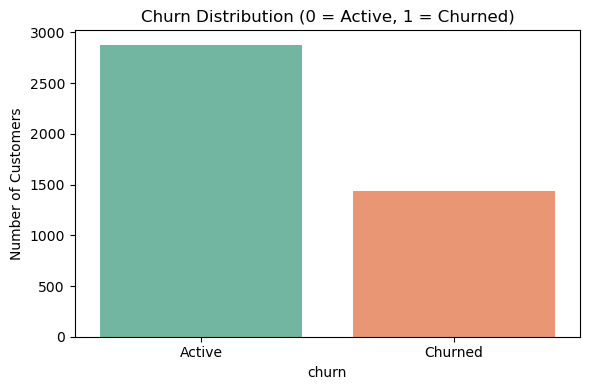

In [6]:
# Label churn: 1 = churned, 0 = active
rfm['churn'] = (rfm['recency'] > 90).astype(int)

# See the balance
print("Churn distribution:")
print(rfm['churn'].value_counts())
print("\nChurn rate:", round(rfm['churn'].mean() * 100, 2), "%")

# Visualize
plt.figure(figsize=(6,4))
sns.countplot(x='churn', data=rfm, palette='Set2')
plt.title('Churn Distribution (0 = Active, 1 = Churned)')
plt.xticks([0,1], ['Active', 'Churned'])
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('../reports/churn_distribution.png')
plt.show()

In [9]:
import sys
!{sys.executable} -m pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


In [10]:
#  Phase 4: Training your Churn Prediction Model
import importlib
import xgboost
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Features and target
X = rfm[['recency', 'frequency', 'monetary']]
y = rfm['churn']

# Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train XGBoost model
model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
model.fit(X_train_scaled, y_train)

# Evaluate
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("AUC-ROC Score:", round(roc_auc_score(y_test, y_prob), 4))

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       576
           1       1.00      0.99      0.99       287

    accuracy                           1.00       863
   macro avg       1.00      0.99      0.99       863
weighted avg       1.00      1.00      1.00       863

AUC-ROC Score: 1.0


In [11]:
# removing recency from the features to work more realisticaly 
# Retrain without recency to avoid data leakage
X = rfm[['frequency', 'monetary']]
y = rfm['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler2 = StandardScaler()
X_train_scaled = scaler2.fit_transform(X_train)
X_test_scaled = scaler2.transform(X_test)

model2 = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
model2.fit(X_train_scaled, y_train)

y_pred2 = model2.predict(X_test_scaled)
y_prob2 = model2.predict_proba(X_test_scaled)[:,1]

print("Classification Report (without recency):")
print(classification_report(y_test, y_pred2))
print("AUC-ROC Score:", round(roc_auc_score(y_test, y_prob2), 4))

Classification Report (without recency):
              precision    recall  f1-score   support

           0       0.74      0.82      0.78       576
           1       0.54      0.41      0.47       287

    accuracy                           0.69       863
   macro avg       0.64      0.62      0.62       863
weighted avg       0.67      0.69      0.68       863

AUC-ROC Score: 0.7092


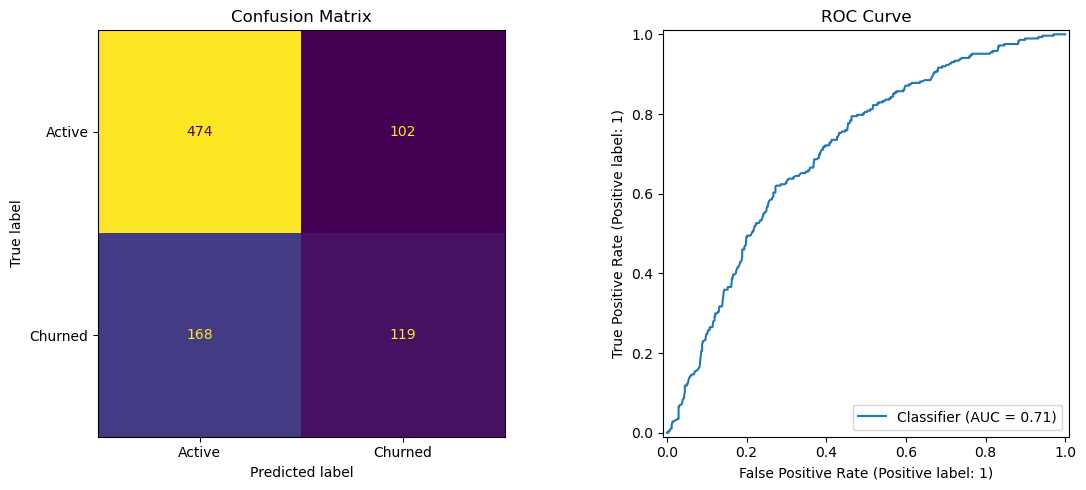

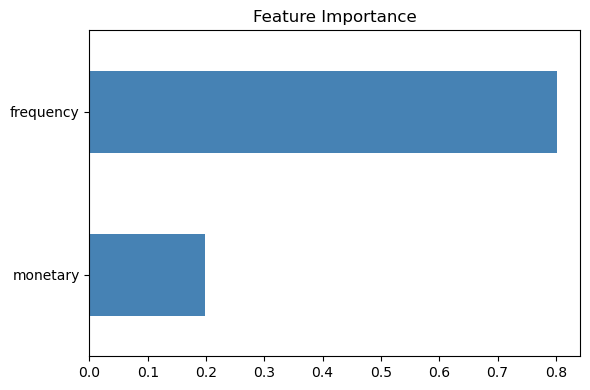

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred2,
    display_labels=['Active', 'Churned'],
    ax=axes[0],
    colorbar=False
)
axes[0].set_title('Confusion Matrix')

# ROC Curve
RocCurveDisplay.from_predictions(
    y_test, y_prob2,
    ax=axes[1]
)
axes[1].set_title('ROC Curve')

plt.tight_layout()
plt.savefig('../reports/model_evaluation.png')
plt.show()

# Feature importance
plt.figure(figsize=(6,4))
feat_imp = pd.Series(model2.feature_importances_, index=['frequency', 'monetary'])
feat_imp.sort_values().plot(kind='barh', color='steelblue')
plt.title('Feature Importance')
plt.tight_layout()
plt.savefig('../reports/feature_importance.png')
plt.show()

In [14]:
import sys
!{sys.executable} -m pip install lifetimes


  Using cached Lifetimes-0.11.3-py3-none-any.whl.metadata (4.8 kB)
  Using cached autograd-1.8.0-py3-none-any.whl.metadata (7.5 kB)
Using cached Lifetimes-0.11.3-py3-none-any.whl (584 kB)
Using cached autograd-1.8.0-py3-none-any.whl (51 kB)

   ---------------------------------------- 0/2 [autograd]
   -------------------- ------------------- 1/2 [lifetimes]
   ---------------------------------------- 2/2 [lifetimes]



In [15]:
#Phase 5: CLV Prediction
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data

# Build the summary data in the format lifetimes expects
summary = summary_data_from_transaction_data(
    df,
    customer_id_col='Customer ID',
    datetime_col='InvoiceDate',
    monetary_value_col='TotalPrice',
    observation_period_end=df['InvoiceDate'].max()
)

print(summary.head(10))
print(summary.shape)

             frequency  recency      T  monetary_value
Customer ID                                           
12346              6.0    196.0  360.0       47.143333
12347              1.0     37.0   39.0      711.790000
12348              0.0      0.0   73.0        0.000000
12349              2.0    182.0  224.0      801.310000
12351              0.0      0.0   10.0        0.000000
12352              1.0     17.0   27.0      200.050000
12353              0.0      0.0   43.0        0.000000
12355              0.0      0.0  202.0        0.000000
12356              2.0     44.0   59.0     1325.905000
12357              0.0      0.0   23.0        0.000000
(4312, 4)


In [17]:
# Increase penalizer to help convergence
bgf = BetaGeoFitter(penalizer_coef=0.5)
bgf.fit(summary['frequency'], summary['recency'], summary['T'])

ggf = GammaGammaFitter(penalizer_coef=0.5)
ggf.fit(returning['frequency'], returning['monetary_value'])

# Predict CLV over next 12 months
summary['predicted_purchases'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    365, summary['frequency'], summary['recency'], summary['T']
)

summary['clv'] = ggf.customer_lifetime_value(
    bgf,
    summary['frequency'],
    summary['recency'],
    summary['T'],
    summary['monetary_value'],
    time=12,
    freq='D'
)

print("CLV Preview:")
print(summary[['frequency', 'monetary_value', 'predicted_purchases', 'clv']].head(10))
print("\nTop 10 most valuable customers:")
print(summary['clv'].sort_values(ascending=False).head(10))

C:\Users\suada\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\suada\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


CLV Preview:
             frequency  monetary_value  predicted_purchases            clv
Customer ID                                                               
12346              6.0       47.143333             5.950151     383.835891
12347              1.0      711.790000             7.132419   -5006.430182
12348              0.0        0.000000                  NaN            NaN
12349              2.0      801.310000             3.416896   82451.343042
12351              0.0        0.000000                  NaN            NaN
12352              1.0      200.050000             8.561416   -1691.153060
12353              0.0        0.000000                  NaN            NaN
12355              0.0        0.000000             0.629141      -0.107717
12356              2.0     1325.905000             9.552059  381361.126281
12357              0.0        0.000000                  NaN            NaN

Top 10 most valuable customers:
Customer ID
12766    388968.358964
12356    381361.126

In [18]:
# Merge CLV predictions with churn predictions
# First reset rfm index to merge properly
rfm = rfm.set_index('Customer ID')

# Combine everything into one master table
master = rfm.join(summary[['predicted_purchases', 'clv']], how='left')

# Clean up: replace negative and NaN CLV with 0
master['clv'] = master['clv'].fillna(0)
master['clv'] = master['clv'].clip(lower=0)

# Add churn probability
master['churn_probability'] = model2.predict_proba(
    scaler2.transform(master[['frequency', 'monetary']])
)[:,1]

# Final preview
print(master.head(10))
print("\nMaster table shape:", master.shape)

# Save to CSV
master.to_csv('../reports/master_customer_table.csv')
print("\nSaved to reports folder!")

             frequency  monetary  recency  churn  predicted_purchases  \
Customer ID                                                             
12346               11    372.86      165      1             5.950151   
12347                2   1323.32        3      0             7.132419   
12348                1    222.16       74      0                  NaN   
12349                3   2671.14       43      0             3.416896   
12351                1    300.93       11      0                  NaN   
12352                2    343.80       11      0             8.561416   
12353                1    317.76       44      0                  NaN   
12355                1    488.21      203      1             0.629141   
12356                3   3562.25       16      0             9.552059   
12357                2  12079.99       24      0                  NaN   

                       clv  churn_probability  
Customer ID                                    
12346           383.835891 

In [ ]:
# master customer table — every customer in one place with their churn risk and predicted lifetime value. ^^^

In [ ]:
# Phase 6: Streamlit Dashboard